In [ ]:
import pandas as pd
import os
import kagglehub

def download_data():
    """Скачивает датасет с Kaggle и возвращает путь к файлу"""
    print("Загрузка датасета...")
    # Скачиваем последнюю версию датасета
    path = kagglehub.dataset_download("vinothkannaece/mobiles-and-laptop-sales-data")

    # Обычно файл лежит в корне скачанной папки
    files = [f for f in os.listdir(path) if f.endswith('.csv')]
    if not files:
        raise FileNotFoundError("CSV файл не найден в скачанном датасете.")

    full_path = os.path.join(path, files[0])
    print(f"Файл скачан: {full_path}")
    return full_path

def clean_data(df):
    # Преобразование дат
    df['Inward Date'] = pd.to_datetime(df['Inward Date'])
    df['Dispatch Date'] = pd.to_datetime(df['Dispatch Date'])

    # Парсинг числовых значений из строк (RAM, ROM, SSD)
    # Удаляет "GB", "TB" и оставляет только цифры
    for col in ['RAM', 'ROM', 'SSD']:
        df[col] = df[col].astype(str).str.extract('(\d+)').fillna(0).astype(int)

    # Заполнение пропусков в специфичных характеристиках
    df['Core Specification'] = df['Core Specification'].fillna('None')
    df['Processor Specification'] = df['Processor Specification'].fillna('None')

    return df

def feature_engineering(df):
    # 1. Время хранения на складе
    df['Days_In_Stock'] = (df['Dispatch Date'] - df['Inward Date']).dt.days

    # 2. Месяц продажи (сезонность)
    df['Month_Sold'] = df['Dispatch Date'].dt.month

    # 3. Флаг премиум-бренда (пример логики)
    premium_brands = ['Apple', 'Samsung']
    df['Is_Premium'] = df['Brand'].apply(lambda x: 1 if x in premium_brands else 0)

    # Удаляем лишнее для обучения (текст, имена, ID)
    to_drop = ['Product Code', 'Product Specification', 'Customer Name',
               'Inward Date', 'Customer Location']
    return df.drop(columns=to_drop)

def run_pipeline():
    # Создаем папки если их нет
    os.makedirs('data/raw', exist_ok=True)
    os.makedirs('data/processed', exist_ok=True)

    # 1. Скачивание
    raw_file_path = download_data()
    df = pd.read_csv(raw_file_path)

    # Сохраняем копию в raw (для структуры проекта)
    df.to_csv('data/raw/sales_data.csv', index=False)

    # 2. Обработка
    df = clean_data(df)
    df = feature_engineering(df)

    # 3. Сохранение финального результата
    output_path = 'data/processed/cleaned_sales.csv'
    df.to_csv(output_path, index=False)
    print(f"Готово! Очищенные данные: {output_path}")

if __name__ == "__main__":
    run_pipeline()

<>:28: SyntaxWarning: invalid escape sequence '\d'
<>:28: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_14552/697928290.py:28: SyntaxWarning: invalid escape sequence '\d'
  df[col] = df[col].astype(str).str.extract('(\d+)').fillna(0).astype(int)


Загрузка датасета...


100%|██████████| 3.09M/3.09M [00:00<00:00, 4.85MB/s]

Extracting files...


Файл скачан: /root/.cache/kagglehub/datasets/vinothkannaece/mobiles-and-laptop-sales-data/versions/1/mobile_sales_data.csv
Готово! Очищенные данные: data/processed/cleaned_sales.csv


In [ ]:
import pandas as pd

def compare_data(raw_path, processed_path):
    df_raw = pd.read_csv(raw_path)
    df_proc = pd.read_csv(processed_path)

    print("=== СРАВНЕНИЕ СТРУКТУРЫ ДАННЫХ ===")
    print(f"Размерность RAW:       {df_raw.shape}")
    print(f"Размерность PROCESSED: {df_proc.shape}")
    print("-" * 30)

    print("=== ТИПЫ ДАННЫХ (Примеры) ===")
    comparison_types = pd.DataFrame({
        'Feature': ['RAM', 'Price', 'Brand'],
        'Raw Type': [df_raw['RAM'].dtype, df_raw['Price'].dtype, df_raw['Brand'].dtype],
        'Proc Type': [df_proc['RAM'].dtype, df_proc['Price'].dtype, df_proc['Brand'].dtype]
    })
    print(comparison_types)
    print("-" * 30)

    print("=== НОВЫЕ ПРИЗНАКИ (Первые 5 строк) ===")
    new_features = ['Days_In_Stock', 'Month_Sold', 'Is_Premium']
    if all(f in df_proc.columns for f in new_features):
        print(df_proc[new_features].head())
    else:
        print("Новые признаки не найдены.")

# Запуск сравнения
if __name__ == "__main__":
    compare_data('data/raw/sales_data.csv', 'data/processed/cleaned_sales.csv')

=== СРАВНЕНИЕ СТРУКТУРЫ ДАННЫХ ===
Размерность RAW:       (50000, 16)
Размерность PROCESSED: (50000, 14)
------------------------------
=== ТИПЫ ДАННЫХ (Примеры) ===
  Feature Raw Type Proc Type
0     RAM   object     int64
1   Price    int64     int64
2   Brand   object    object
------------------------------
=== НОВЫЕ ПРИЗНАКИ (Первые 5 строк) ===
   Days_In_Stock  Month_Sold  Is_Premium
0              1           8           0
1              3          10           0
2              1           3           1
3             50           3           0
4             31           9           0


In [ ]:
import pandas as pd

def check_duplicates_report(raw_path, processed_path):
    df_raw = pd.read_csv(raw_path)
    df_proc = pd.read_csv(processed_path)

    # 1. Проверка на полные дубликаты (строка в строку)
    raw_dupes = df_raw.duplicated().sum()
    proc_dupes = df_proc.duplicated().sum()

    # 2. Проверка по бизнес-ключам (если есть риск, что один заказ записан дважды)
    # Например, если один и тот же клиент купил тот же товар в ту же секунду
    business_keys = ['Product', 'Brand', 'Price', 'Quantity Sold', 'Region']
    biz_dupes_raw = df_raw.duplicated(subset=[col for col in business_keys if col in df_raw.columns]).sum()

    print("=== ОТЧЕТ ПО ДУБЛИКАТАМ ===")
    print(f"Полные дубликаты в RAW:       {raw_dupes}")
    print(f"Полные дубликаты в PROCESSED: {proc_dupes}")
    print("-" * 30)
    print(f"Подозрительные совпадения (по ключам) в RAW: {biz_dupes_raw}")

    if proc_dupes == 0:
        print("РЕЗУЛЬТАТ: Очистка выполнена успешно. Полных дубликатов нет.")
    else:
        print(f"ВНИМАНИЕ: В обработанных данных осталось {proc_dupes} дублей!")

# Запуск
check_duplicates_report('data/raw/sales_data.csv', 'data/processed/cleaned_sales.csv')

=== ОТЧЕТ ПО ДУБЛИКАТАМ ===
Полные дубликаты в RAW:       0
Полные дубликаты в PROCESSED: 0
------------------------------
Подозрительные совпадения (по ключам) в RAW: 2
РЕЗУЛЬТАТ: Очистка выполнена успешно. Полных дубликатов нет.


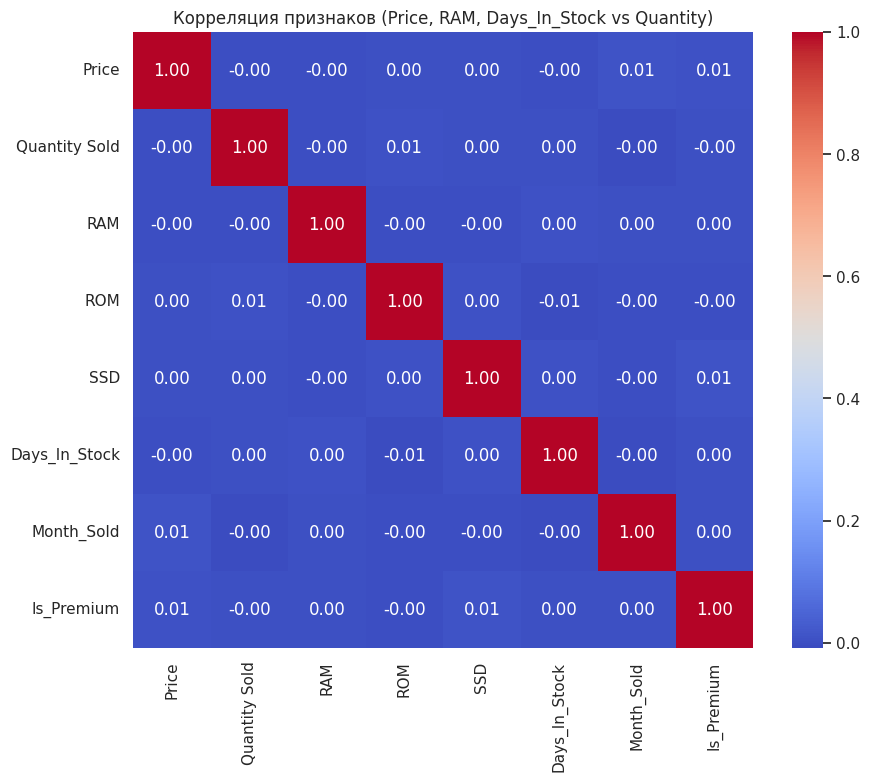

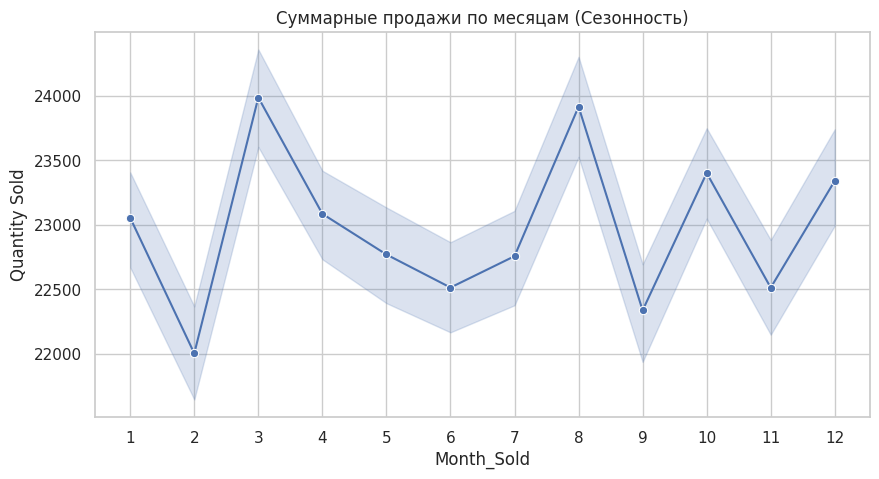

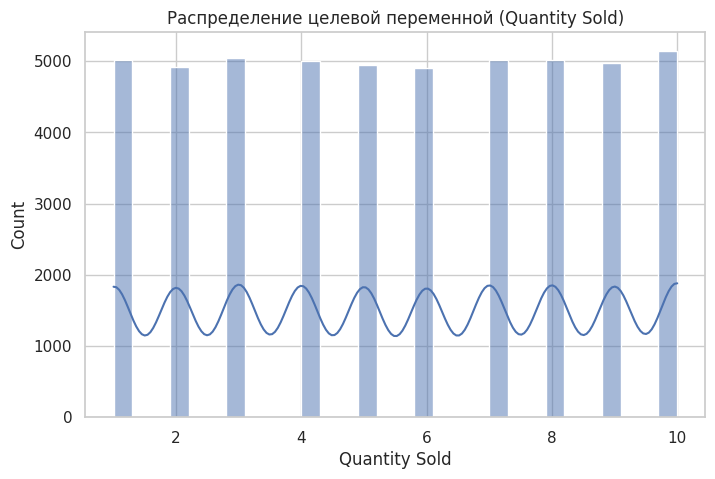

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def generate_visualizations(df):
    # Установка стиля
    sns.set_theme(style="whitegrid")

    # 1. Матрица корреляции (числовые признаки)
    plt.figure(figsize=(10, 8))
    numeric_df = df.select_dtypes(include=[np.number])
    sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Корреляция признаков (Price, RAM, Days_In_Stock vs Quantity)')
    plt.show()

    # 2. Сезонность: Продажи по месяцам
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=df, x='Month_Sold', y='Quantity Sold', estimator='sum', marker='o')
    plt.title('Суммарные продажи по месяцам (Сезонность)')
    plt.xticks(range(1, 13))
    plt.show()

    # 3. Распределение таргета (проверка на выбросы)
    plt.figure(figsize=(8, 5))
    sns.histplot(df['Quantity Sold'], kde=True, bins=30)
    plt.title('Распределение целевой переменной (Quantity Sold)')
    plt.show()

# Запуск
df_processed = pd.read_csv('data/processed/cleaned_sales.csv')
generate_visualizations(df_processed)

In [ ]:
def split_data_chronologically(df, target_col='Quantity Sold'):
    """
    Разделение данных 70/15/15 без перемешивания для временных рядов
    """
    df = df.sort_values('Dispatch Date')
    df = df.drop(columns=['Dispatch Date'])
    n = len(df)
    train_end = int(n * 0.7)
    val_end = int(n * 0.85)

    train = df.iloc[:train_end]
    val = df.iloc[train_end:val_end]
    test = df.iloc[val_end:]

    X_train = train.drop(columns=[target_col]).select_dtypes(include=[np.number])
    y_train = train[target_col]

    X_val = val.drop(columns=[target_col]).select_dtypes(include=[np.number])
    y_val = val[target_col]

    X_test = test.drop(columns=[target_col]).select_dtypes(include=[np.number])
    y_test = test[target_col]

    print(f"Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")
    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = split_data_chronologically(df_processed)

Train size: 35000, Val size: 7500, Test size: 7500


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error

SEED = 42

def fast_training(X_train, y_train, X_test, y_test):
    configs = {
        "Ridge": (Ridge(), {"alpha": [0.1, 1.0, 10.0]}),
        "RandomForest": (RandomForestRegressor(random_state=SEED), {"n_estimators": [50, 100]}),
        "ExtraTrees": (ExtraTreesRegressor(random_state=SEED), {"n_estimators": [50, 100]}),
        "XGBoost": (XGBRegressor(random_state=SEED), {"n_estimators": [50, 100], "learning_rate": [0.1]}),
        "LightGBM": (LGBMRegressor(random_state=SEED, verbose=-1), {"n_estimators": [50, 100]})
    }

    results = []

    for name, (model, params) in configs.items():
        print(f"Обучаю {name}...")

        # Перебор параметров (GridSearch)
        grid = GridSearchCV(model, params, cv=2, scoring='neg_mean_absolute_error')
        grid.fit(X_train, y_train)

        # Считаем ошибку на тесте
        best_model = grid.best_estimator_
        preds = best_model.predict(X_test)
        mae = mean_absolute_error(y_test, preds)

        results.append({
            "Модель": name,
            "Ошибка (MAE)": round(mae, 4),
            "Лучшие параметры": grid.best_params_
        })

    return pd.DataFrame(results)

# Запуск
report_table = fast_training(X_train, y_train, X_test, y_test)


Обучаю Ridge...
Обучаю RandomForest...
Обучаю ExtraTrees...
Обучаю XGBoost...
Обучаю LightGBM...


In [ ]:
report_table

,Модель,Ошибка (MAE),Лучшие параметры
0,Ridge,2.4939,{'alpha': 10.0}
1,RandomForest,2.5439,{'n_estimators': 100}
2,ExtraTrees,2.6165,{'n_estimators': 100}
3,XGBoost,2.4967,"{'learning_rate': 0.1, 'n_estimators': 50}"
4,LightGBM,2.4961,{'n_estimators': 50}


Выполняю PCA...
Выполняю TruncatedSVD...
Выполняю t-SNE...


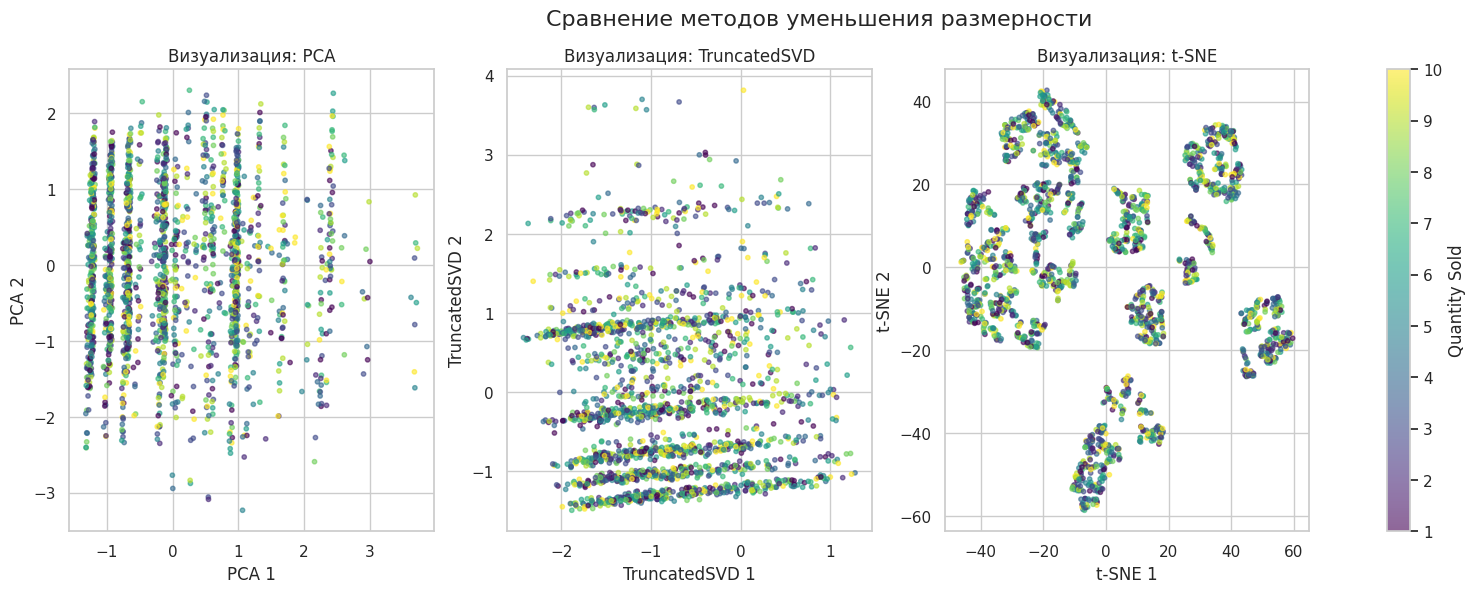

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

def compare_dimension_reduction(X, y):
    # Масштабирование обязательно для PCA/SVD
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    subset_size = min(2000, len(X_scaled))
    X_subs = X_scaled[:subset_size]
    y_subs = y[:subset_size]

    # Инициализация методов
    methods = {
        "PCA": PCA(n_components=2),
        "TruncatedSVD": TruncatedSVD(n_components=2),
        "t-SNE": TSNE(n_components=2, perplexity=30, random_state=42)
    }

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    for ax, (name, method) in zip(axes, methods.items()):
        print(f"Выполняю {name}...")
        components = method.fit_transform(X_subs)

        scatter = ax.scatter(components[:, 0], components[:, 1],
                            c=y_subs, cmap='viridis', alpha=0.6, s=10)
        ax.set_title(f"Визуализация: {name}")
        ax.set_xlabel(f"{name} 1")
        ax.set_ylabel(f"{name} 2")

    plt.colorbar(scatter, ax=axes, label='Quantity Sold')
    plt.suptitle("Сравнение методов уменьшения размерности", fontsize=16)
    plt.show()

compare_dimension_reduction(X_train, y_train)